In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mobiles-dataset-2025/Mobiles Dataset (2025).csv


# <p style="background-color: #e0f7fa; font-size: 120%; text-align: center; border-radius: 15px; color: #1a1a1a; font-weight: bold; font-family: 'Helvetica', 'Arial', sans-serif; border: 5px solid #00796B; padding: 15px; margin: 15px;">Analyzing Mobile Trends: 2025</p>

## Dataset Description:
#### This dataset contains information on various mobile devices, including specifications, pricing, and performance metrics. It covers attributes such as brand, model, processor, RAM, storage, camera specifications, battery capacity, display details, operating system, and launch year. The dataset is useful for analyzing trends in mobile technology, comparing device features, and identifying market patterns in 2025.

# <p style="background-color: #e0f7fa; font-size: 120%; text-align: center; border-radius: 15px; color: #1a1a1a; font-weight: bold; font-family: 'Helvetica', 'Arial', sans-serif; border: 5px solid #00796B; padding: 15px; margin: 15px;">Import libraries</p>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# <p style="background-color: #e0f7fa; font-size: 120%; text-align: center; border-radius: 15px; color: #1a1a1a; font-weight: bold; font-family: 'Helvetica', 'Arial', sans-serif; border: 5px solid #00796B; padding: 15px; margin: 15px;">Import Dataset</p>

In [3]:
df = pd.read_csv("/kaggle/input/mobiles-dataset-2025/Mobiles Dataset (2025).csv", encoding='latin1')

In [4]:
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
0,Apple,iPhone 16 128GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 224,999","INR 79,999","CNY 5,799",USD 799,"AED 2,799",2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 234,999","INR 84,999","CNY 6,099",USD 849,"AED 2,999",2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,"PKR 244,999","INR 89,999","CNY 6,499",USD 899,"AED 3,199",2024
3,Apple,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 249,999","INR 89,999","CNY 6,199",USD 899,"AED 3,199",2024
4,Apple,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,"PKR 259,999","INR 94,999","CNY 6,499",USD 949,"AED 3,399",2024


In [5]:
df.tail()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (Pakistan),Launched Price (India),Launched Price (China),Launched Price (USA),Launched Price (Dubai),Launched Year
925,Poco,Pad 5G 128GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 66,220","INR 23,999","CNY 2,099",USD 280,"AED 1,029",2024
926,Poco,Pad 5G 256GB,571g,8GB,8MP,8MP,Snapdragon 7s Gen 2,"10,000mAh",12.1 inches,"PKR 71,220","INR 25,999","CNY 2,299",USD 300,"AED 1,099",2024
927,Samsung,Galaxy Z Fold6 256GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 604,999","INR 164,999","¥13,999","USD 1,899","AED 7,199",2024
928,Samsung,Galaxy Z Fold6 512GB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,"PKR 544,999","INR 176,999","CNY 15,999",USD 1719,"AED 7,699",2024
929,Samsung,Galaxy Z Fold6 1TB,239g,12GB,"10MP, 4MP (UDC)",50MP,Snapdragon 8 Gen 3,4400mAh,7.6 inches,Not available,"INR 200,999","CNY 17,999","USD 2,259","AED 8,699",2024


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Company Name               930 non-null    object
 1   Model Name                 930 non-null    object
 2   Mobile Weight              930 non-null    object
 3   RAM                        930 non-null    object
 4   Front Camera               930 non-null    object
 5   Back Camera                930 non-null    object
 6   Processor                  930 non-null    object
 7   Battery Capacity           930 non-null    object
 8   Screen Size                930 non-null    object
 9   Launched Price (Pakistan)  930 non-null    object
 10  Launched Price (India)     930 non-null    object
 11  Launched Price (China)     930 non-null    object
 12  Launched Price (USA)       930 non-null    object
 13  Launched Price (Dubai)     930 non-null    object
 14  Launched Y

In [7]:
df.describe()

,Launched Year
count,930.000000
mean,2022.193548
std,1.862080
min,2014.000000
25%,2021.000000
50%,2023.000000
75%,2024.000000
max,2025.000000


In [8]:
df.dtypes

Company Name                 object
Model Name                   object
Mobile Weight                object
RAM                          object
Front Camera                 object
Back Camera                  object
Processor                    object
Battery Capacity             object
Screen Size                  object
Launched Price (Pakistan)    object
Launched Price (India)       object
Launched Price (China)       object
Launched Price (USA)         object
Launched Price (Dubai)       object
Launched Year                 int64
dtype: object

In [9]:
df.columns

Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)',
       'Launched Price (Dubai)', 'Launched Year'],
      dtype='object')

In [10]:
df.count

<bound method DataFrame.count of     Company Name            Model Name Mobile Weight   RAM     Front Camera  \
0          Apple       iPhone 16 128GB          174g   6GB             12MP   
1          Apple       iPhone 16 256GB          174g   6GB             12MP   
2          Apple       iPhone 16 512GB          174g   6GB             12MP   
3          Apple  iPhone 16 Plus 128GB          203g   6GB             12MP   
4          Apple  iPhone 16 Plus 256GB          203g   6GB             12MP   
..           ...                   ...           ...   ...              ...   
925         Poco          Pad 5G 128GB          571g   8GB              8MP   
926         Poco          Pad 5G 256GB          571g   8GB              8MP   
927      Samsung  Galaxy Z Fold6 256GB          239g  12GB  10MP, 4MP (UDC)   
928      Samsung  Galaxy Z Fold6 512GB          239g  12GB  10MP, 4MP (UDC)   
929      Samsung    Galaxy Z Fold6 1TB          239g  12GB  10MP, 4MP (UDC)   

    Back Camera   

In [11]:
df.isnull().sum()

Company Name                 0
Model Name                   0
Mobile Weight                0
RAM                          0
Front Camera                 0
Back Camera                  0
Processor                    0
Battery Capacity             0
Screen Size                  0
Launched Price (Pakistan)    0
Launched Price (India)       0
Launched Price (China)       0
Launched Price (USA)         0
Launched Price (Dubai)       0
Launched Year                0
dtype: int64

In [12]:
df. duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
925    False
926    False
927    False
928    False
929    False
Length: 930, dtype: bool

# <p style="background-color: #e0f7fa; font-size: 120%; text-align: center; border-radius: 15px; color: #1a1a1a; font-weight: bold; font-family: 'Helvetica', 'Arial', sans-serif; border: 5px solid #00796B; padding: 15px; margin: 15px;">EDA</p>

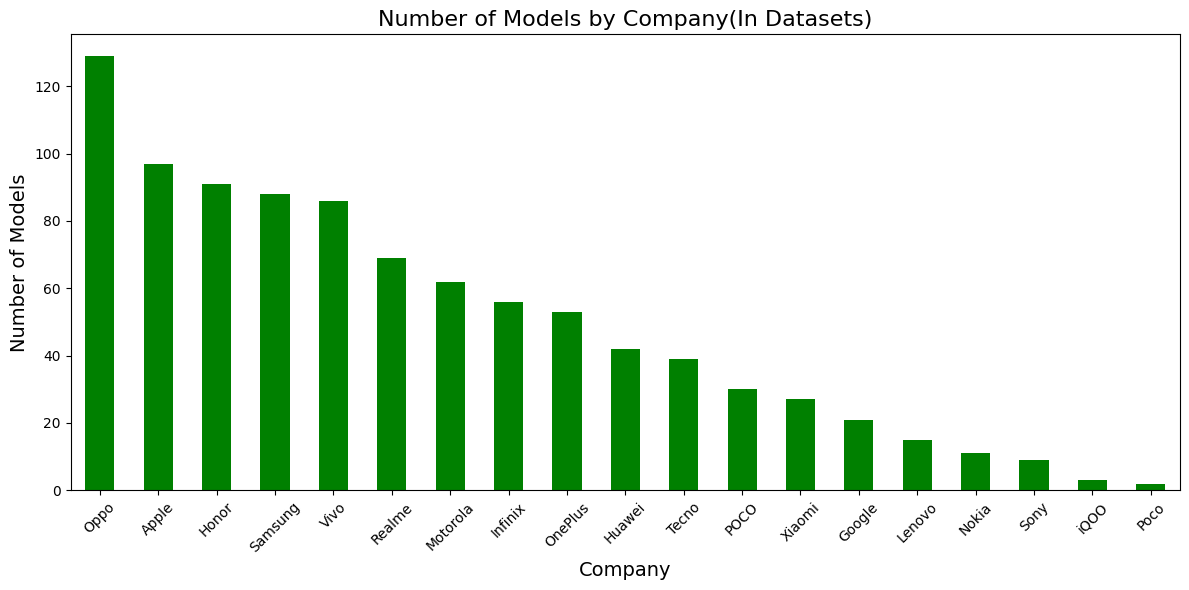

In [13]:
model_count_by_company = df['Company Name'].value_counts()


plt.figure(figsize=(12, 6))
model_count_by_company.plot(kind='bar', color='green')
plt.title('Number of Models by Company(In Datasets)', fontsize=16)
plt.xlabel('Company', fontsize=14)
plt.ylabel('Number of Models', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


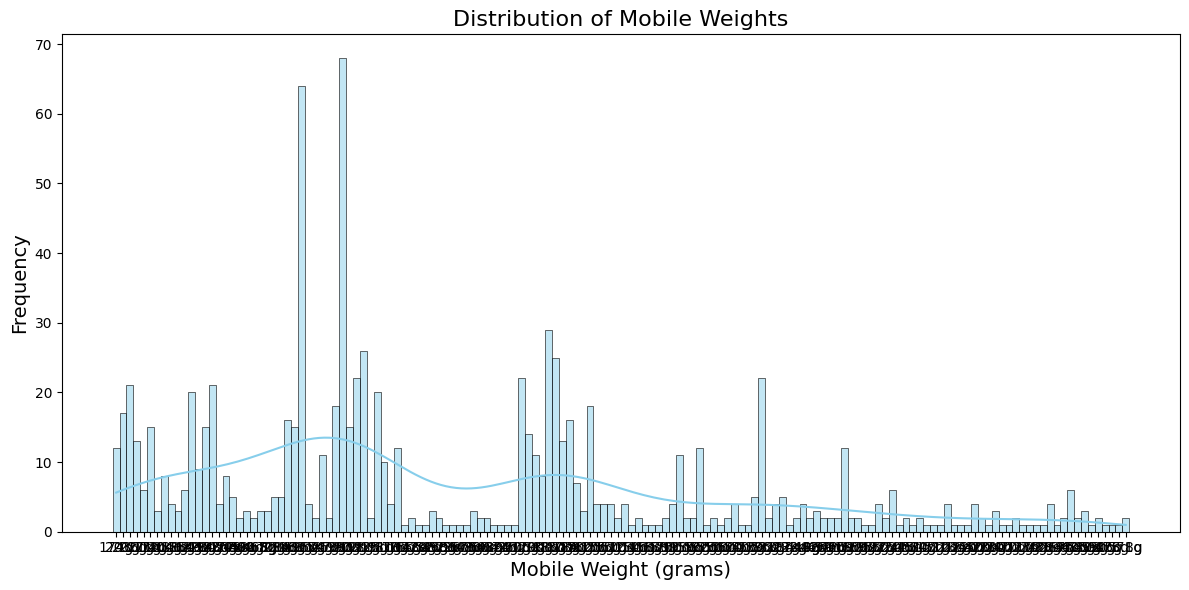

In [14]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Mobile Weight'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Mobile Weights', fontsize=16)
plt.xlabel('Mobile Weight (grams)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.tight_layout()
plt.show()

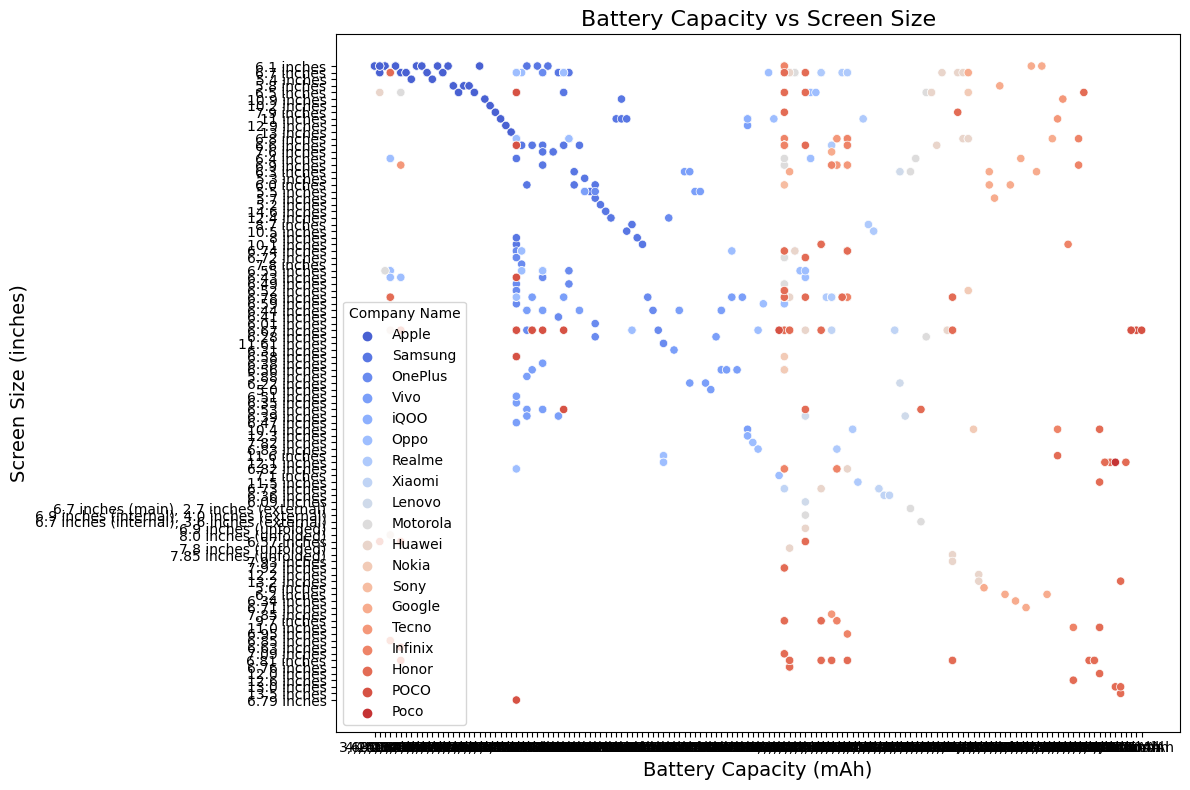

In [15]:
# Plot Battery Capacity vs Screen Size
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Battery Capacity', y='Screen Size', data=df, hue='Company Name', palette='coolwarm')
plt.title('Battery Capacity vs Screen Size', fontsize=16)
plt.xlabel('Battery Capacity (mAh)', fontsize=14)
plt.ylabel('Screen Size (inches)', fontsize=14)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


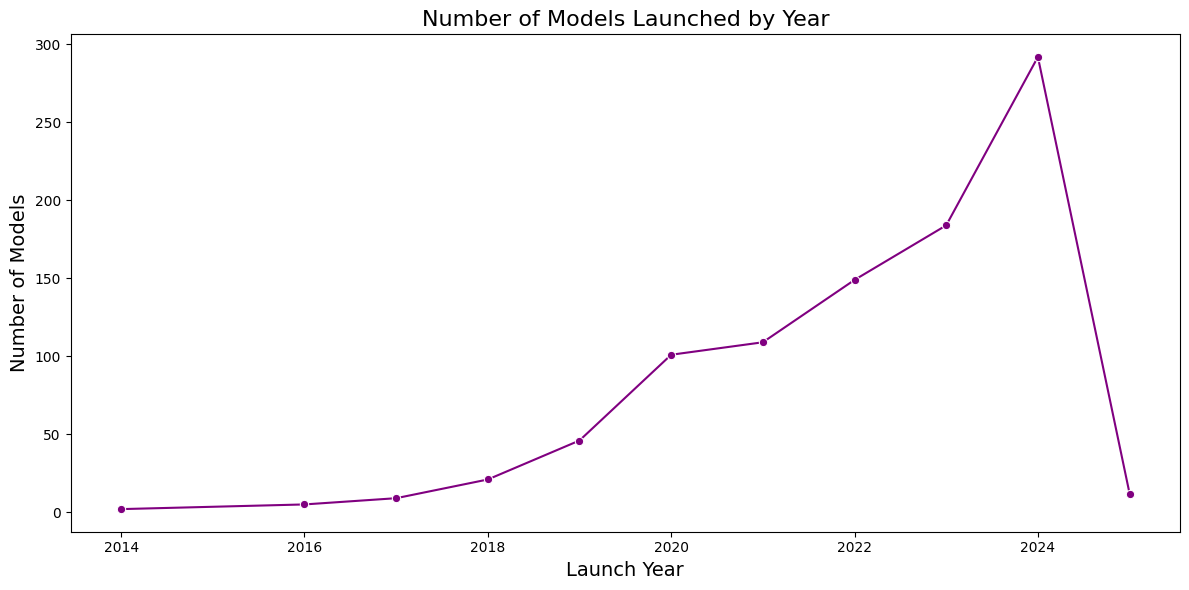

In [16]:
# Count the number of models launched by year
launch_year_count = df['Launched Year'].value_counts().sort_index()

# Plot top launch years
plt.figure(figsize=(12, 6))
sns.lineplot(x=launch_year_count.index, y=launch_year_count.values, marker="o", color='purple')
plt.title('Number of Models Launched by Year', fontsize=16)
plt.xlabel('Launch Year', fontsize=14)
plt.ylabel('Number of Models', fontsize=14)
plt.tight_layout()
plt.show()


<ipython-input-17-154afde5d09b>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Launched Price (Pakistan)'] = pd.to_numeric(df['Launched Price (Pakistan)'], errors='coerce')


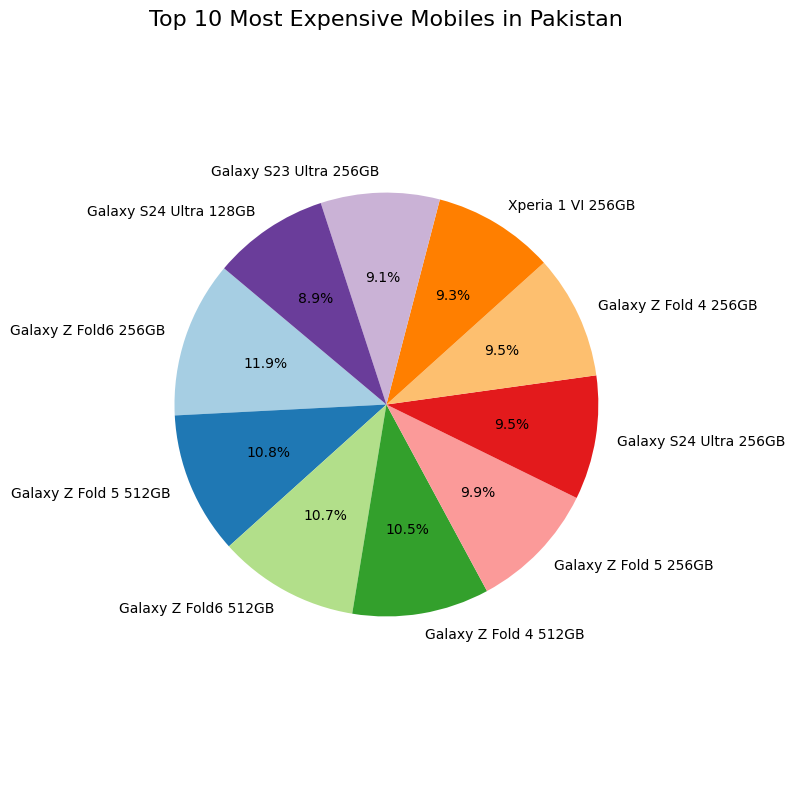

In [17]:
def clean_price(price):
    if isinstance(price, str):
        price = price.replace('PKR', '').replace(',', '').strip()
        if price.isdigit():
            return int(price)
    return None

# Assuming 'df' is your dataframe
df['Launched Price (Pakistan)'] = df['Launched Price (Pakistan)'].apply(clean_price)
df = df.dropna(subset=['Launched Price (Pakistan)'])
df['Launched Price (Pakistan)'] = pd.to_numeric(df['Launched Price (Pakistan)'], errors='coerce')

top_10_expensive_mobiles = df.nlargest(10, 'Launched Price (Pakistan)')

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(top_10_expensive_mobiles['Launched Price (Pakistan)'], labels=top_10_expensive_mobiles['Model Name'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Top 10 Most Expensive Mobiles in Pakistan', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

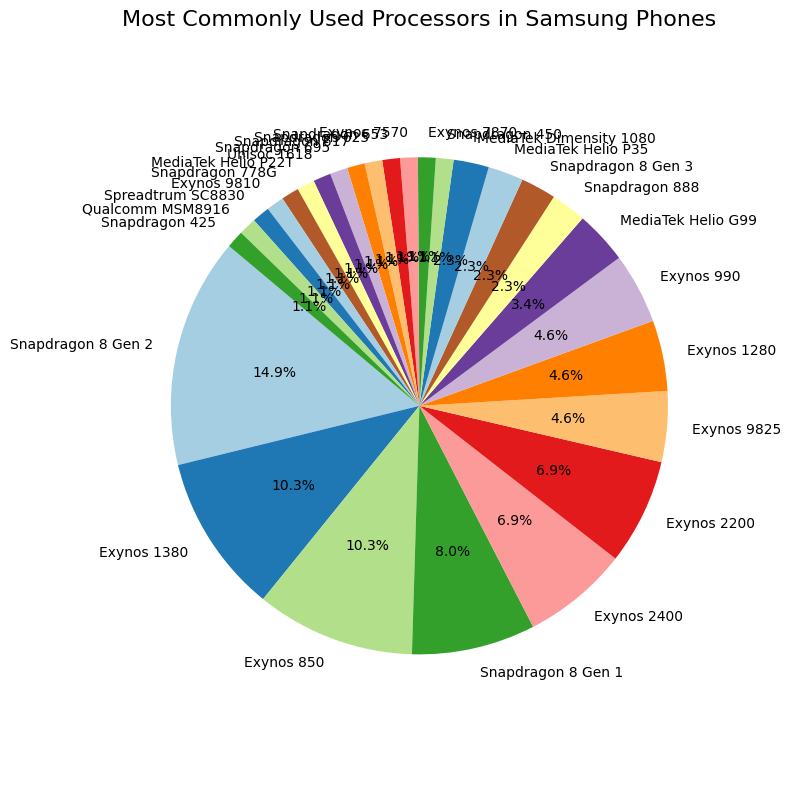

In [18]:
samsung_phones = df[df['Company Name'].str.lower() == 'samsung']

processor_counts = samsung_phones['Processor'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(processor_counts, labels=processor_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Most Commonly Used Processors in Samsung Phones', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

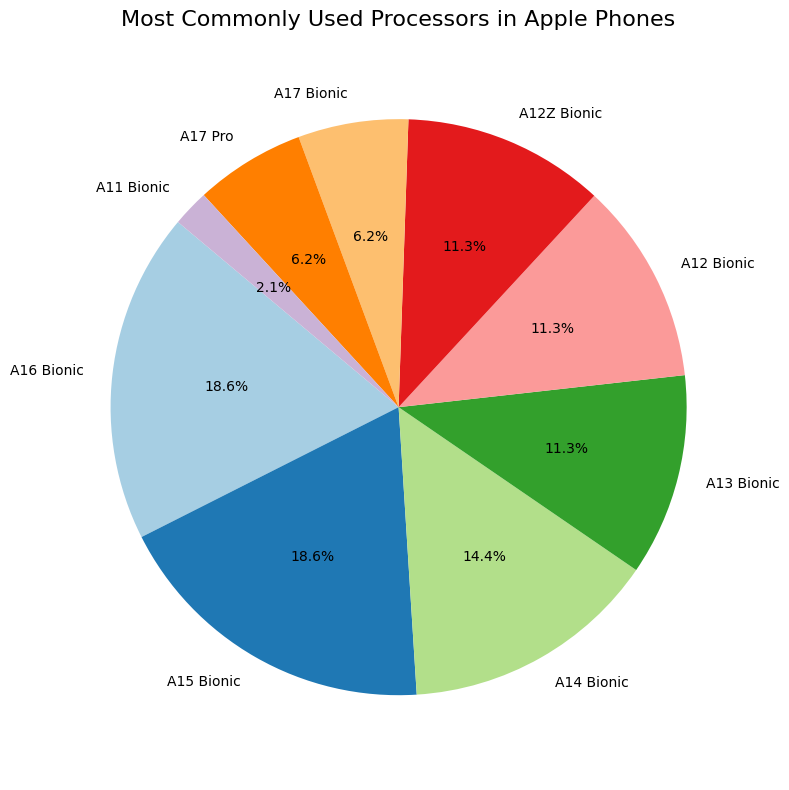

In [19]:
apple_phones = df[df['Company Name'].str.lower() == 'apple']

processor_counts = apple_phones['Processor'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(processor_counts, labels=processor_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Most Commonly Used Processors in Apple Phones', fontsize=16)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.tight_layout()
plt.show()

In [20]:
samsung_phones = df[df['Company Name'].str.lower() == 'samsung']

samsung_2024 = samsung_phones[samsung_phones['Launched Year'] == 2024]

if not samsung_2024.empty:
    print("Samsung Phones Launched in 2024:")
    print(samsung_2024[['Company Name', 'Model Name', 'RAM', 'Battery Capacity', 'Screen Size']])
else:
    print("No Samsung phones were launched in 2024.")

print('--------------------------------phone related in 2025--------------------------')

phones_2025 = df[df['Launched Year'] == 2025]

if not phones_2025.empty:
    print("Phones Released in 2025:")
    print(phones_2025[['Company Name', 'Model Name','RAM', 'Battery Capacity', 'Screen Size']])
else:
    print("No phones were released in 2025.")

Samsung Phones Launched in 2024:
    Company Name                 Model Name   RAM Battery Capacity Screen Size
97       Samsung     Galaxy S24 Ultra 128GB  12GB          5000mAh  6.8 inches
98       Samsung     Galaxy S24 Ultra 256GB  12GB          5000mAh  6.8 inches
99       Samsung          Galaxy S24+ 128GB   8GB          4800mAh  6.6 inches
100      Samsung          Galaxy S24+ 256GB   8GB          4800mAh  6.6 inches
101      Samsung           Galaxy S24 128GB   8GB          4000mAh  6.1 inches
102      Samsung           Galaxy S24 256GB   8GB          4000mAh  6.1 inches
177      Samsung  Galaxy Tab Active 5 128GB   6GB          5050mAh    8 inches
927      Samsung       Galaxy Z Fold6 256GB  12GB          4400mAh  7.6 inches
928      Samsung       Galaxy Z Fold6 512GB  12GB          4400mAh  7.6 inches
--------------------------------phone related in 2025--------------------------
Phones Released in 2025:
    Company Name         Model Name   RAM Battery Capacity  Screen Size


In [21]:
from sklearn.model_selection import train_test_split

In [22]:
print(df.columns)

Index(['Company Name', 'Model Name', 'Mobile Weight', 'RAM', 'Front Camera',
       'Back Camera', 'Processor', 'Battery Capacity', 'Screen Size',
       'Launched Price (Pakistan)', 'Launched Price (India)',
       'Launched Price (China)', 'Launched Price (USA)',
       'Launched Price (Dubai)', 'Launched Year'],
      dtype='object')


In [23]:
# Check if 'Company Name' or similar exists in the columns
df.columns[df.columns.str.contains('Company', case=False)]


Index(['Company Name'], dtype='object')

In [24]:
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]   

In [25]:
X = pd.get_dummies(X, drop_first=True)

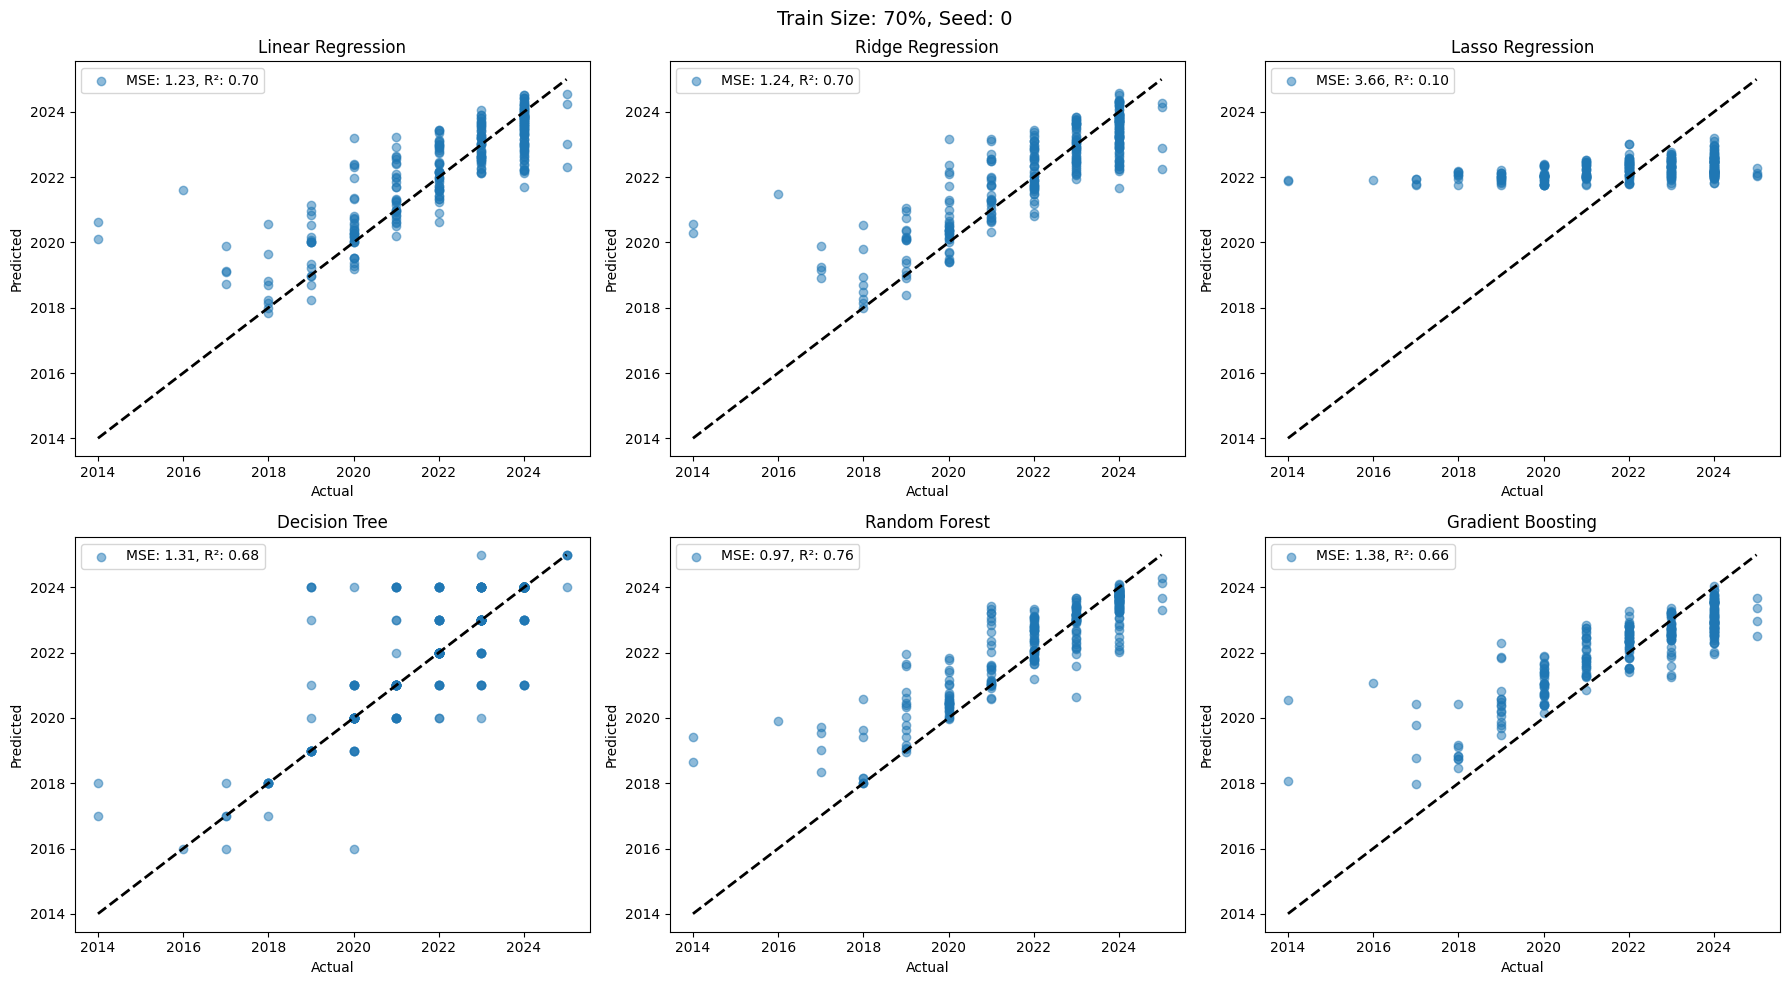

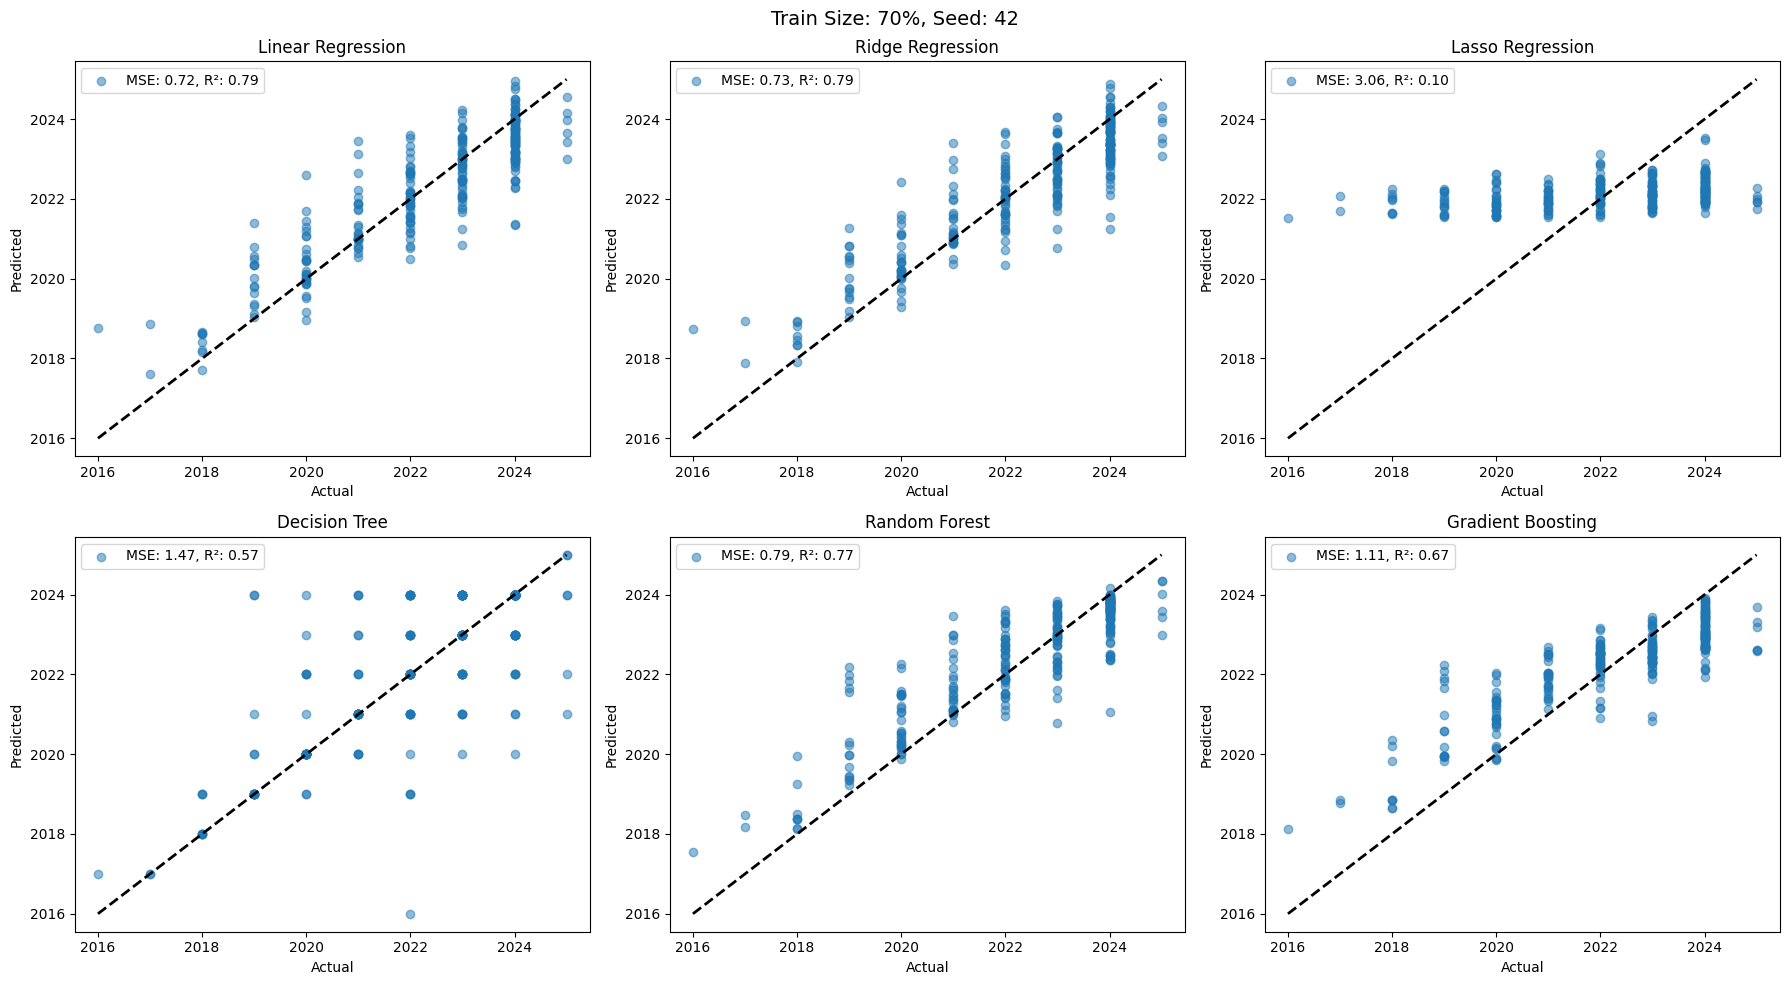

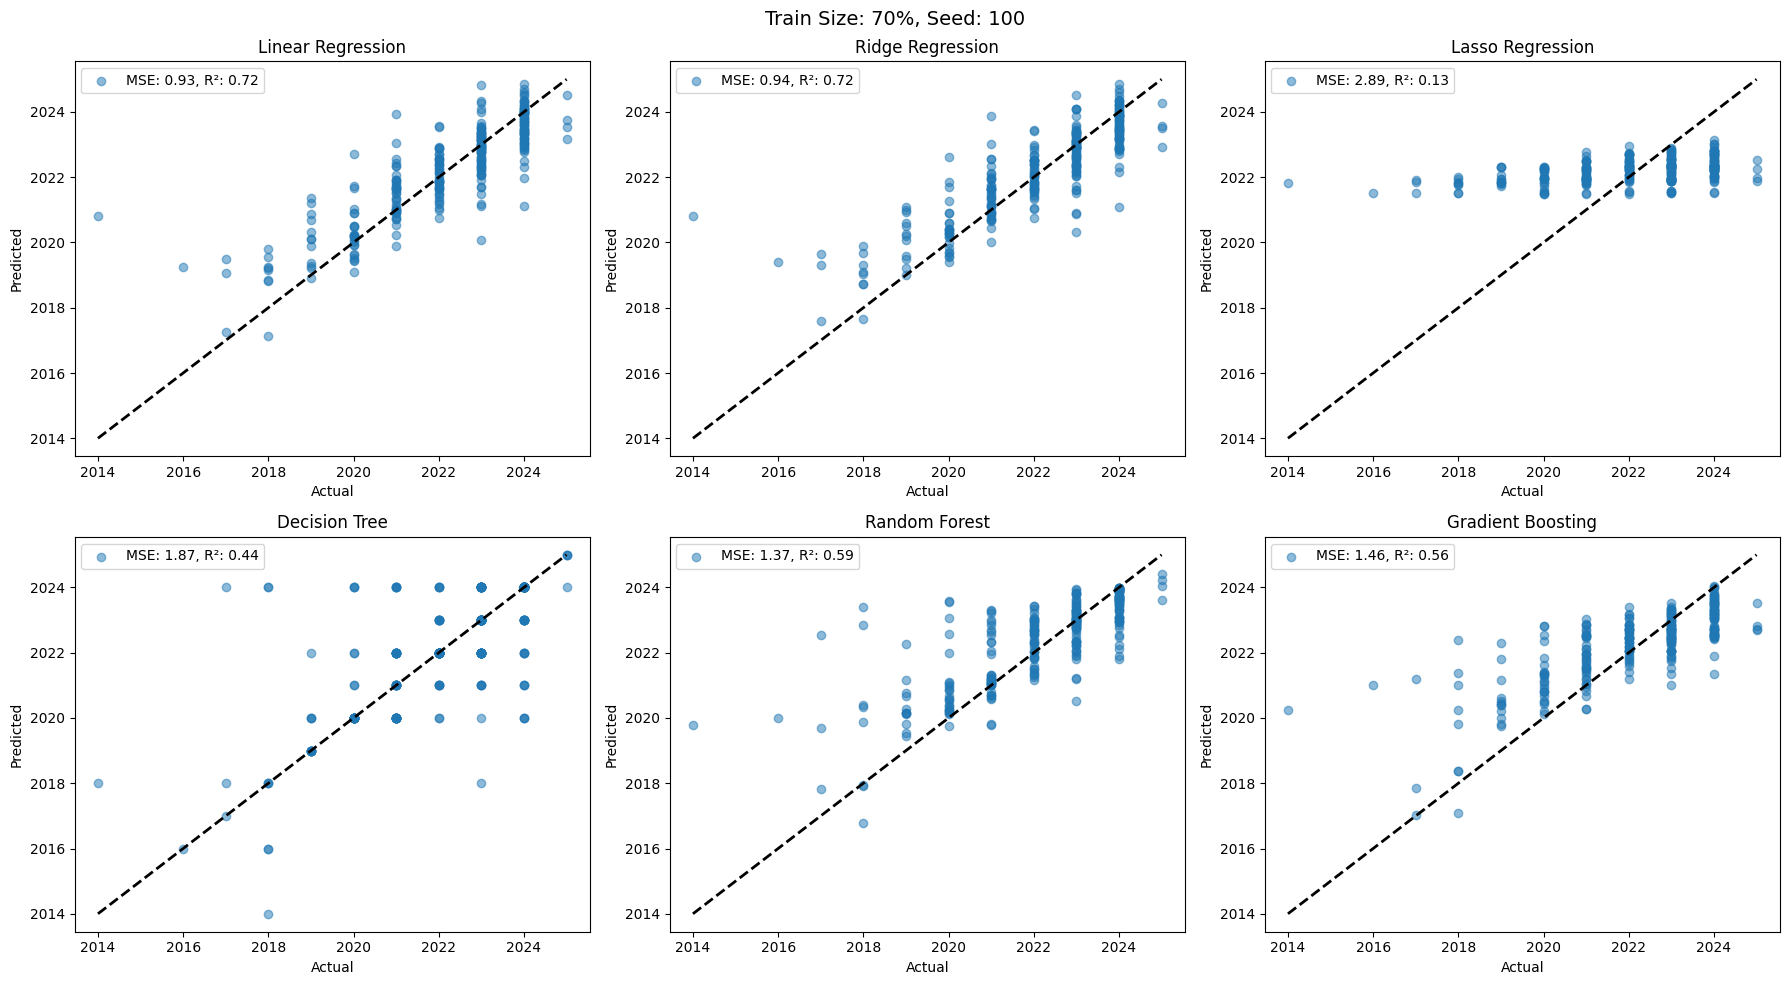

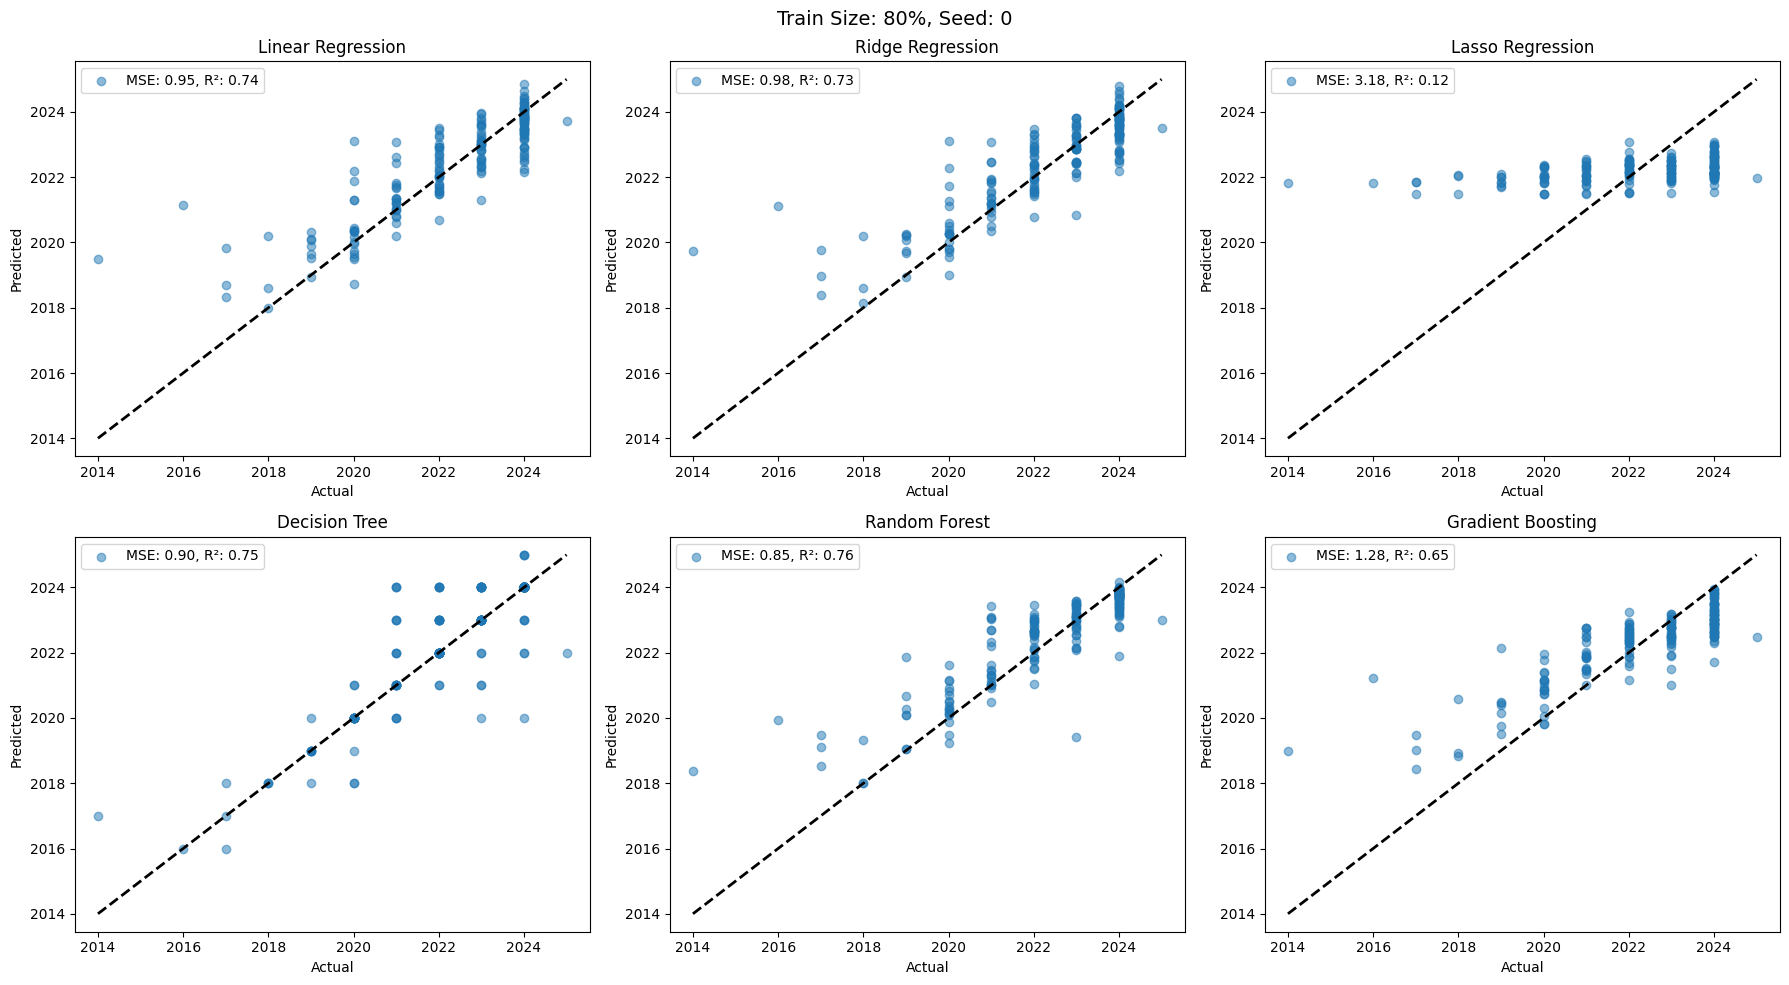

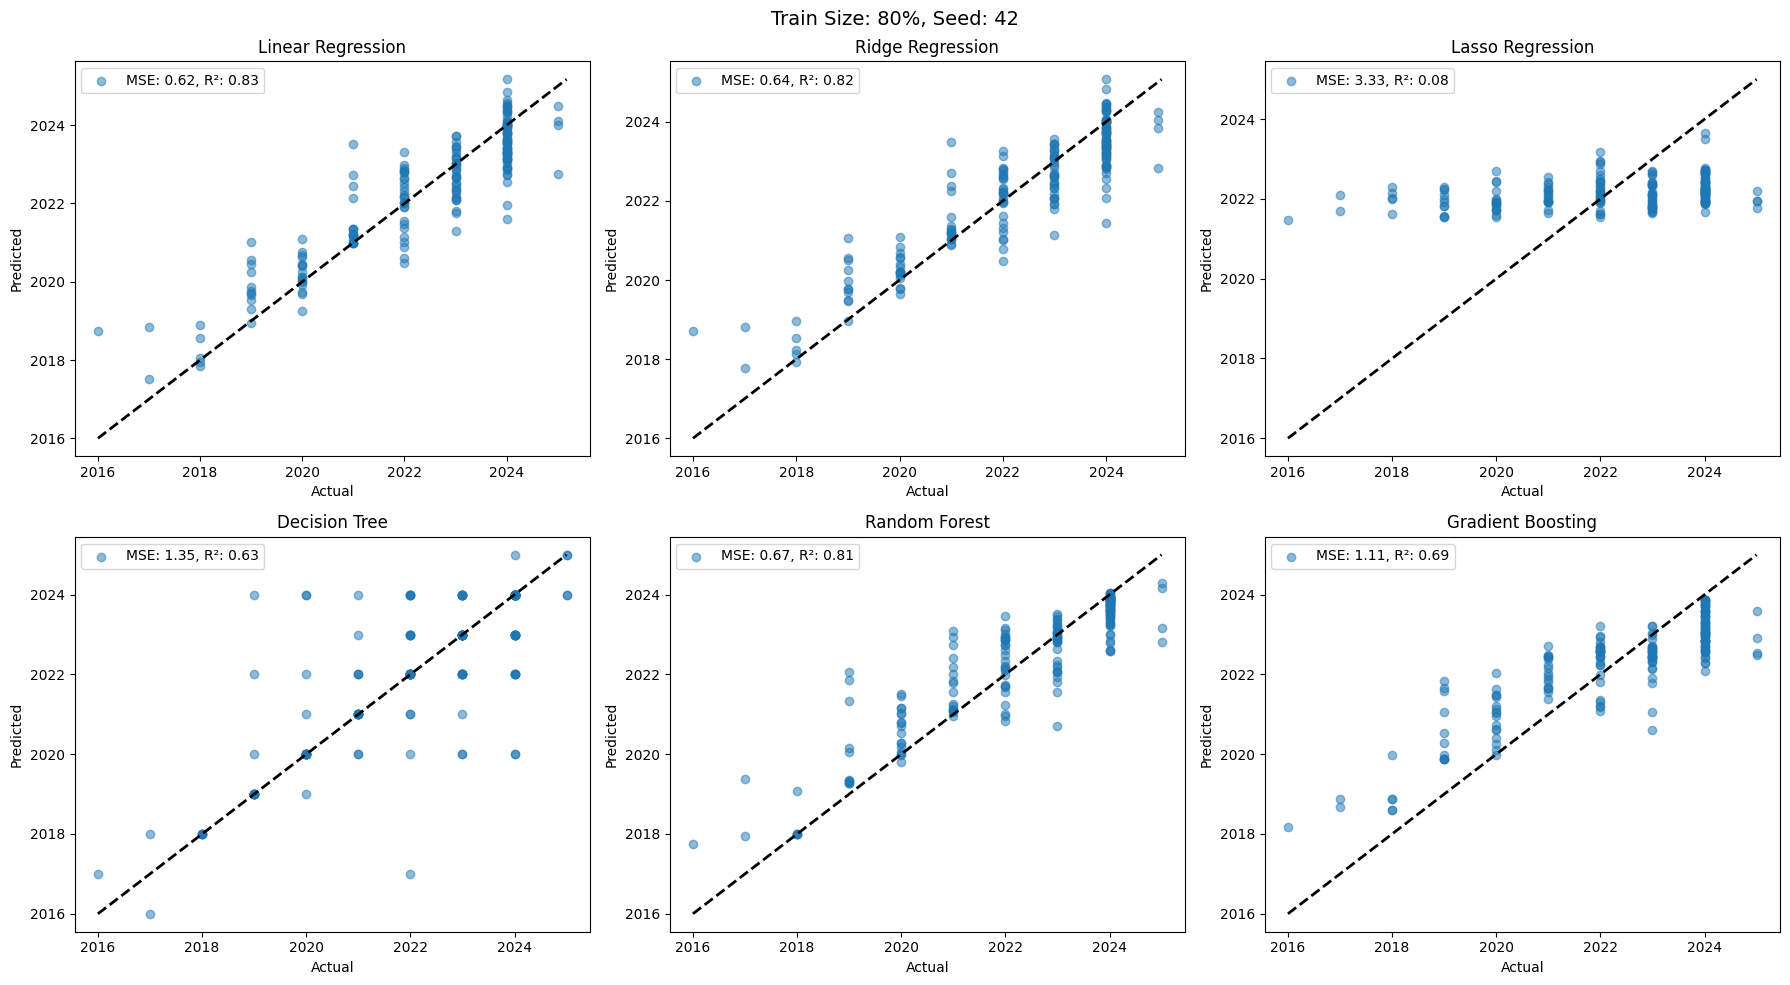

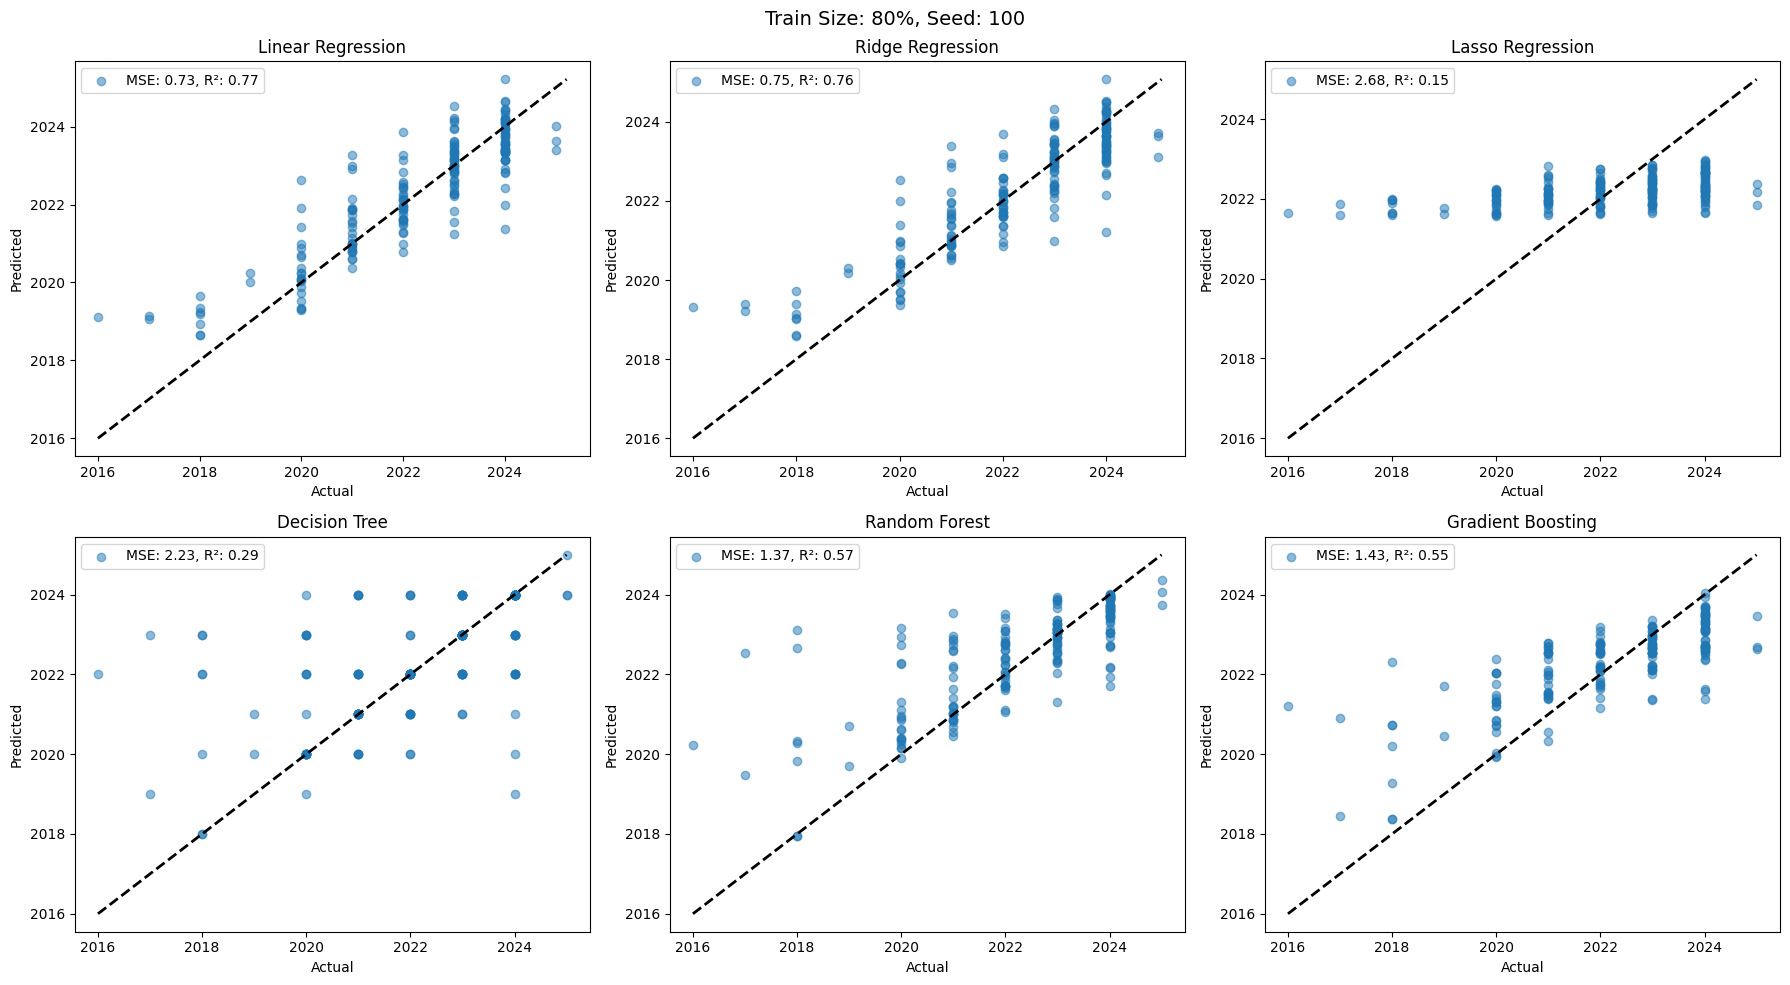

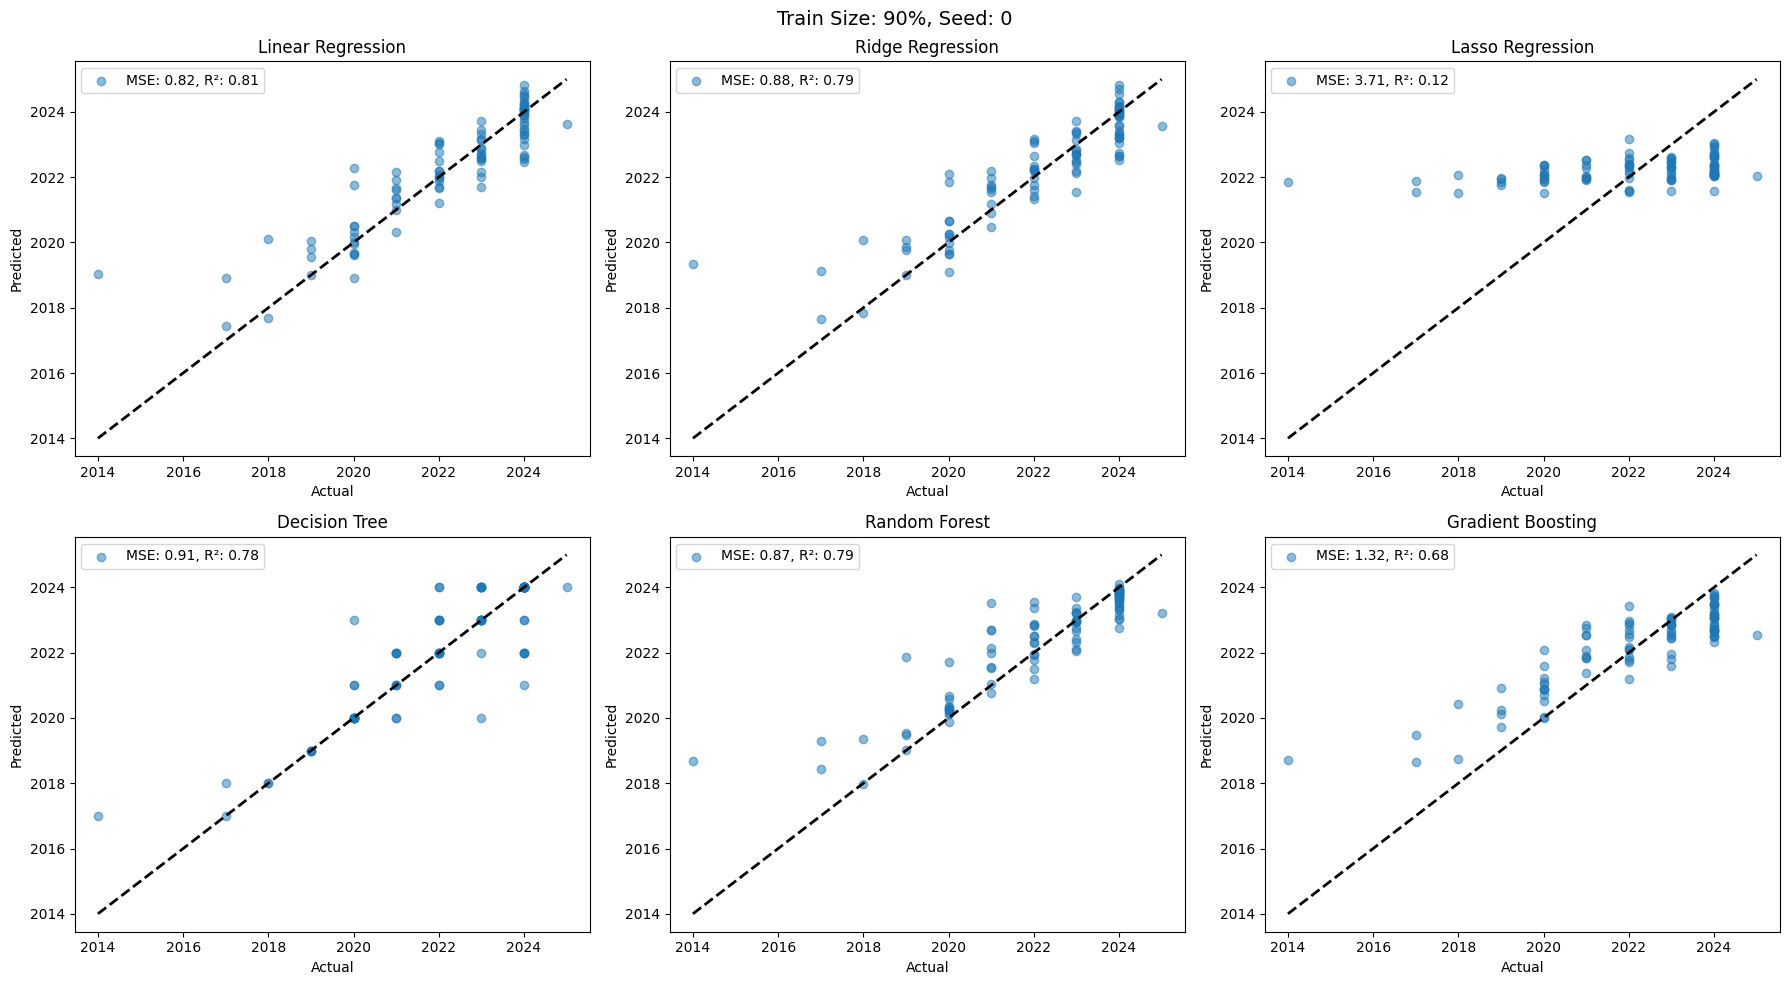

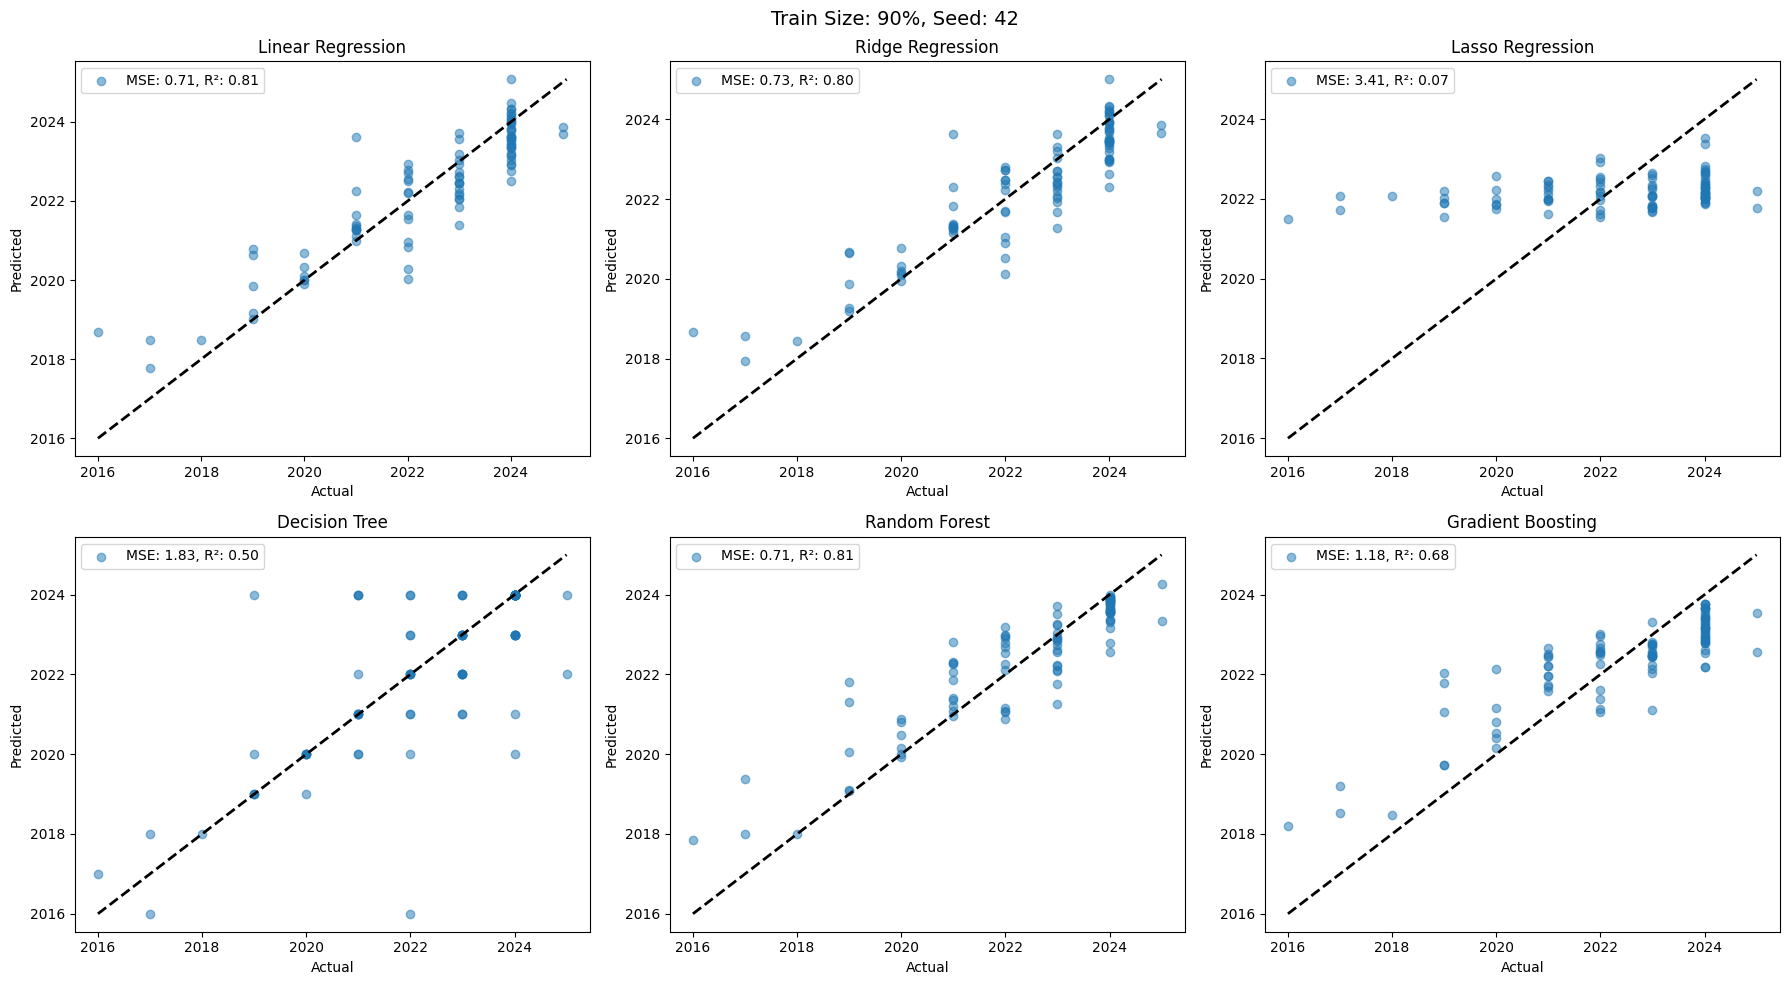

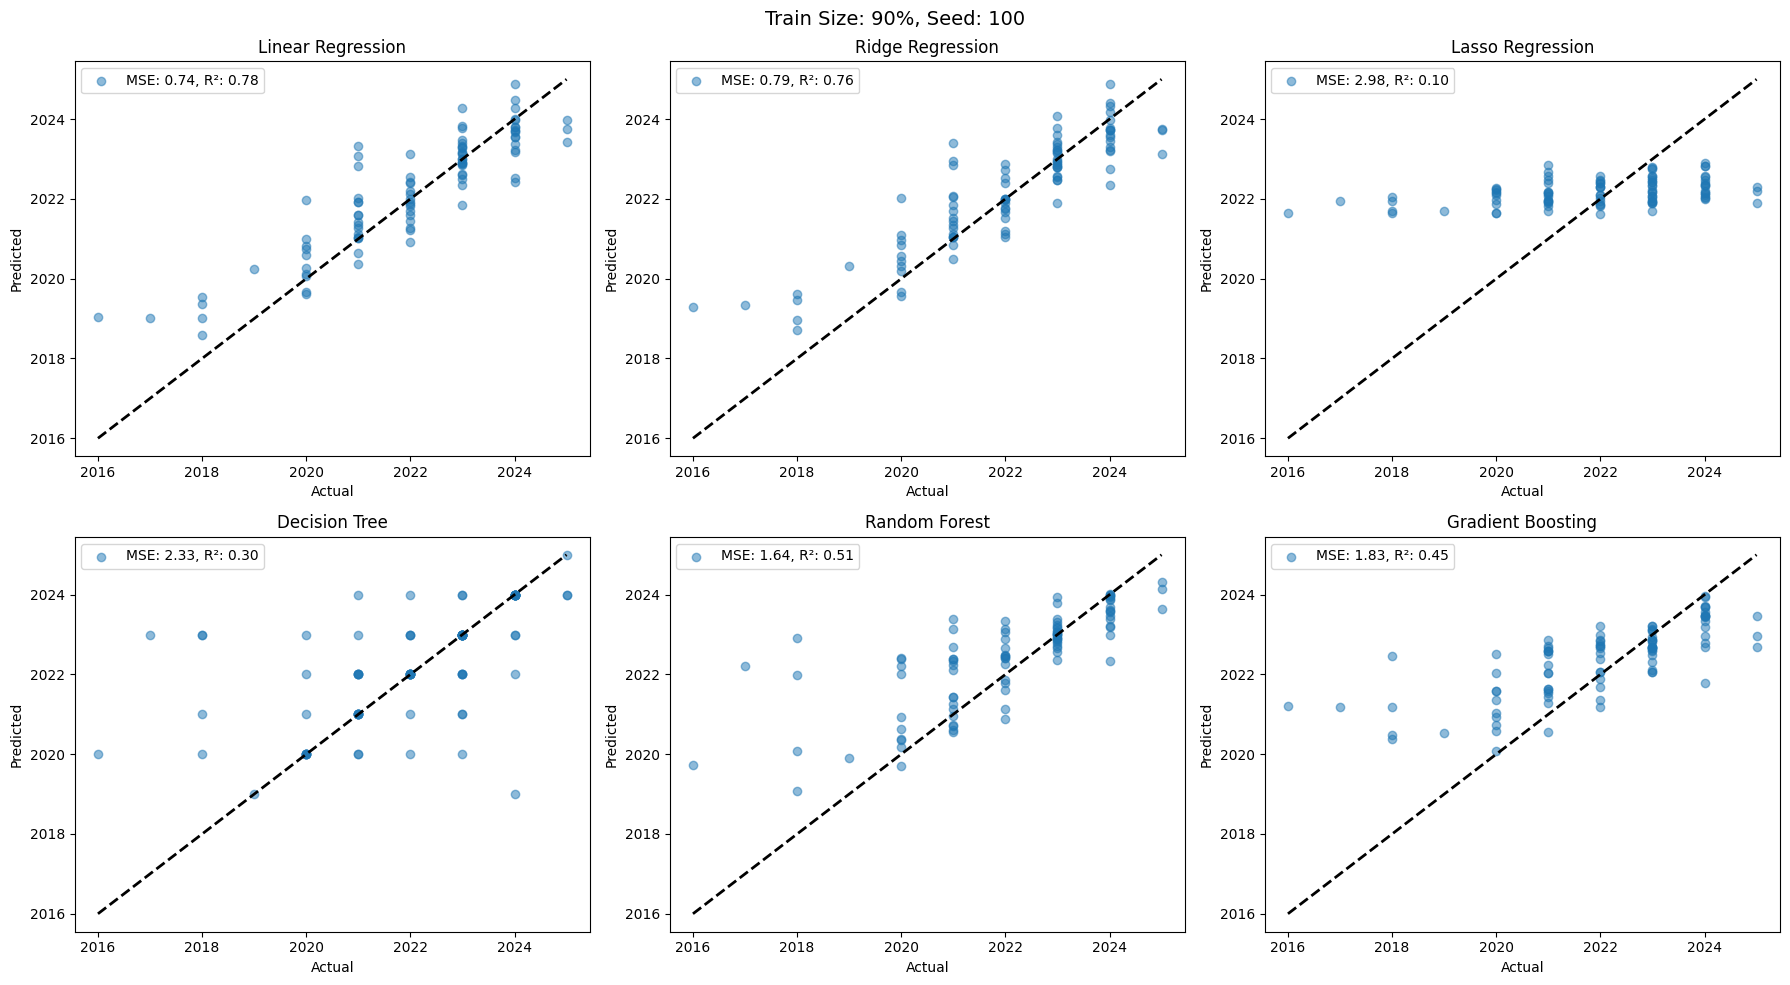

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

def perform_regression(X, y, train_size, random_seed):
    # Splitting data
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=train_size, random_state=random_seed)
    
    # Define regression models
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=1.0),
        "Lasso Regression": Lasso(alpha=0.1),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor(n_estimators=100, random_state=random_seed),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=random_seed),
    }

    results = []
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Evaluation Metrics
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        results.append((name, mse, r2, y_pred))

    # Plot Results
    fig, axs = plt.subplots(2, 3, figsize=(18, 10))  # 2 rows, 3 columns
    axs = axs.flatten()  # Flatten for easy iteration

    for i, (name, mse, r2, y_pred) in enumerate(results):
        axs[i].scatter(y_test, y_pred, alpha=0.5, label=f'MSE: {mse:.2f}, R²: {r2:.2f}')
        min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
        axs[i].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2)
        axs[i].set_title(name)
        axs[i].set_xlabel('Actual')
        axs[i].set_ylabel('Predicted')
        axs[i].legend()

    plt.suptitle(f'Train Size: {train_size*100:.0f}%, Seed: {random_seed}', fontsize=14)
    plt.tight_layout()
    plt.show()

    return results

# Running with different train sizes and seeds
train_sizes = [0.7, 0.8, 0.9]
random_seeds = [0, 42, 100]

for train_size in train_sizes:
    for seed in random_seeds:
        perform_regression(X, y, train_size, seed)
